<a href="https://colab.research.google.com/github/ierigeri/Practica-1/blob/Tranque-el-mauro/Tranque%20el%20Mauro%202.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import platform, sys, os
if 'google.colab' in sys.modules:
    # install PyGMTSAR stable version from PyPI
    !{sys.executable} -m pip install -q pygmtsar 'scipy==1.11.4'
    import importlib.resources as resources
    with resources.as_file(resources.files('pygmtsar.data') / 'google_colab.sh') as google_colab_script_filename:
        !sh {google_colab_script_filename}
    # enable custom widget manager as required by recent Google Colab updates
    from google.colab import output
    output.enable_custom_widget_manager()
    # initialize virtual framebuffer for interactive 3D visualization; required for headless environments
    import xvfbwrapper
    display = xvfbwrapper.Xvfb(width=800, height=600)
    display.start()

# specify GMTSAR installation path
PATH = os.environ['PATH']
if PATH.find('GMTSAR') == -1:
    PATH = os.environ['PATH'] + ':/usr/local/GMTSAR/bin/'
    %env PATH {PATH}

# display PyGMTSAR version
from pygmtsar import __version__
__version__

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.6/97.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.0/105.0 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 k

'2024.8.30.post5'

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import geopandas as gpd
import json
import shapely
from dask.distributed import Client
import psutil
import dask

In [4]:
# plotting modules
import pyvista as pv
# magic trick for white background
pv.set_plot_theme("document")
import panel
panel.extension(comms='ipywidgets')
panel.extension('vtk')
from contextlib import contextmanager
import matplotlib.pyplot as plt
@contextmanager
def mpl_settings(settings):
    original_settings = {k: plt.rcParams[k] for k in settings}
    plt.rcParams.update(settings)
    yield
    plt.rcParams.update(original_settings)
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.titlesize'] = 24
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
%matplotlib inline

In [5]:
# define Pandas display settings
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 100)

In [6]:
from pygmtsar import S1, Stack, tqdm_dask, ASF, Tiles, XYZTiles

Procesamiento de Imágenes Sentinel-1


In [7]:
ORBIT        = 'D'
SUBSWATH     = 2

In [8]:
SCENES = ['S1A_IW_SLC__1SDV_20230219T100406_20230219T100433_047303_05AD5B_EB5A',
          'S1A_IW_SLC__1SDV_20240214T100411_20240214T100438_052553_065B52_20D2',
          'S1A_IW_SLC__1SDV_20250103T100407_20250103T100434_057278_070BF6_5B3C']
SUBSWATH = 2

In [9]:
WORKDIR      = 'raw_kal'
DATADIR      = 'data_kal'

In [10]:
# define DEM and landmask filenames inside data directory
DEM = f'{DATADIR}/dem_alta_resolucion.nc'

In [11]:
geojson = '''
{
  "type": "Feature",
  "geometry": {
    "type": "LineString",
    "coordinates": [[-71.0854, -31.9941], [-70.8933, -31.9941], [-70.8933, -31.9074], [-71.0854, -31.9074], [-71.0854, -31.9941]]
  },
  "properties": {}
}
'''
AOI = gpd.GeoDataFrame.from_features([json.loads(geojson)])

In [12]:
# Set these variables to None and you will be prompted to enter your username and password below.
asf_username = 'GoogleColab2023'
asf_password = 'GoogleColab_2023'

In [13]:
# Set these variables to None and you will be prompted to enter your username and password below.
asf = ASF(asf_username, asf_password)
# Optimized scene downloading from ASF - only the required subswaths and polarizations.
# Subswaths are already encoded in burst identifiers and are only needed for scenes.
print(asf.download(DATADIR, SCENES, SUBSWATH))


ASF Downloading Sentinel-1 SLC::   0%|          | 0/3 [00:00<?, ?it/s]

                                                        burst_or_scene
0  S1A_IW_SLC__1SDV_20230219T100406_20230219T100433_047303_05AD5B_EB5A
1  S1A_IW_SLC__1SDV_20240214T100411_20240214T100438_052553_065B52_20D2
2  S1A_IW_SLC__1SDV_20250103T100407_20250103T100434_057278_070BF6_5B3C


In [14]:
S1.download_orbits(DATADIR, S1.scan_slc(DATADIR))

,orbit
0,S1A_OPER_AUX_POEORB_OPOD_20230311T080753_V20230218T225942_20230220T005942.EOF.zip
1,S1A_OPER_AUX_POEORB_OPOD_20240305T070751_V20240213T225942_20240215T005942.EOF.zip
2,S1A_OPER_AUX_RESORB_OPOD_20250103T112115_V20250103T072704_20250103T104434.EOF.zip


Tiles Parallel Downloading:   0%|          | 0/2 [00:00<?, ?it/s]

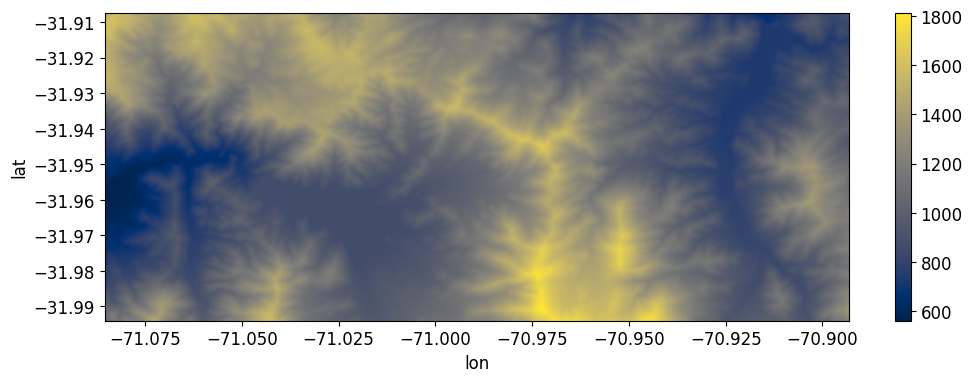

In [15]:
Tiles().download_dem(AOI, filename=DEM).plot.imshow(cmap='cividis')


In [16]:
# simple Dask initialization
if 'client' in globals():
    client.close()
client = Client()
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
INFO:distributed.scheduler:State start
INFO:distributed.scheduler:  Scheduler at:     tcp://127.0.0.1:35723
INFO:distributed.scheduler:  dashboard at:  http://127.0.0.1:8787/status
INFO:distributed.scheduler:Registering Worker plugin shuffle
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:37879'
INFO:distributed.nanny:        Start Nanny at: 'tcp://127.0.0.1:35363'
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:40293', name: 1, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker compute stream, tcp://127.0.0.1:40293
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:34634
INFO:distributed.scheduler:Register worker <WorkerState 'tcp://127.0.0.1:39667', name: 0, status: init, memory: 0, processing: 0>
INFO:distributed.scheduler:Starting worker co

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 2,Total memory: 12.67 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35723,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 2
Started: Just now,Total memory: 12.67 GiB
Comm: tcp://127.0.0.1:39667,Total threads: 1
Dashboard: http://127.0.0.1:44313/status,Memory: 6.34 GiB
Nanny: tcp://127.0.0.1:37879,


In [17]:
scenes = S1.scan_slc(DATADIR, subswath=SUBSWATH)

In [18]:
sbas = Stack(WORKDIR, drop_if_exists=True).set_scenes(scenes)
sbas.to_dataframe()


NOTE: auto set reference scene 2023-02-19. You can change it like Stack.set_reference("2022-01-20")


,datetime,orbit,mission,polarization,subswath,datapath,metapath,noisepath,calibpath,orbitpath,geometry
date,,,,,,,,,,,
2023-02-19,2023-02-19 10:04:08,D,S1A,VV,2,data_kal/S1A_IW_SLC__1SDV_20230219T100406_20230219T100433_047303_05AD5B_EB5A.SAFE/measurement/s1...,data_kal/S1A_IW_SLC__1SDV_20230219T100406_20230219T100433_047303_05AD5B_EB5A.SAFE/annotation/s1a...,None,None,data_kal/S1A_OPER_AUX_POEORB_OPOD_20230311T080753_V20230218T225942_20230220T005942.EOF,"MULTIPOLYGON (((-70.49758 -31.4175, -70.55081 -31.40496, -70.60444 -31.3923, -70.65353 -31.38069..."
2024-02-14,2024-02-14 10:04:13,D,S1A,VV,2,data_kal/S1A_IW_SLC__1SDV_20240214T100411_20240214T100438_052553_065B52_20D2.SAFE/measurement/s1...,data_kal/S1A_IW_SLC__1SDV_20240214T100411_20240214T100438_052553_065B52_20D2.SAFE/annotation/s1a...,None,None,data_kal/S1A_OPER_AUX_POEORB_OPOD_20240305T070751_V20240213T225942_20240215T005942.EOF,"MULTIPOLYGON (((-70.49839 -31.41726, -70.55097 -31.40487, -70.60398 -31.39235, -70.65245 -31.380..."
2025-01-03,2025-01-03 10:04:08,D,S1A,VV,2,data_kal/S1A_IW_SLC__1SDV_20250103T100407_20250103T100434_057278_070BF6_5B3C.SAFE/measurement/s1...,data_kal/S1A_IW_SLC__1SDV_20250103T100407_20250103T100434_057278_070BF6_5B3C.SAFE/annotation/s1a...,None,None,data_kal/S1A_OPER_AUX_RESORB_OPOD_20250103T112115_V20250103T072704_20250103T104434.EOF,"MULTIPOLYGON (((-70.49738 -31.41727, -70.54996 -31.40489, -70.60296 -31.39237, -70.65143 -31.380..."


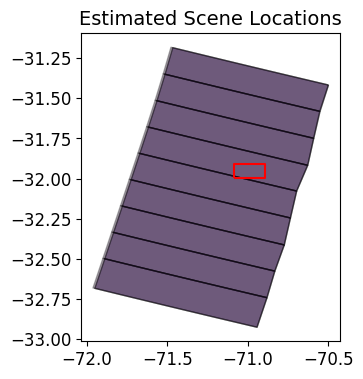

In [19]:
sbas.plot_scenes(AOI=AOI, aspect='equal')


In [20]:
sbas.compute_reframe(AOI)


Reframing:   0%|          | 0/3 [00:00<?, ?it/s]

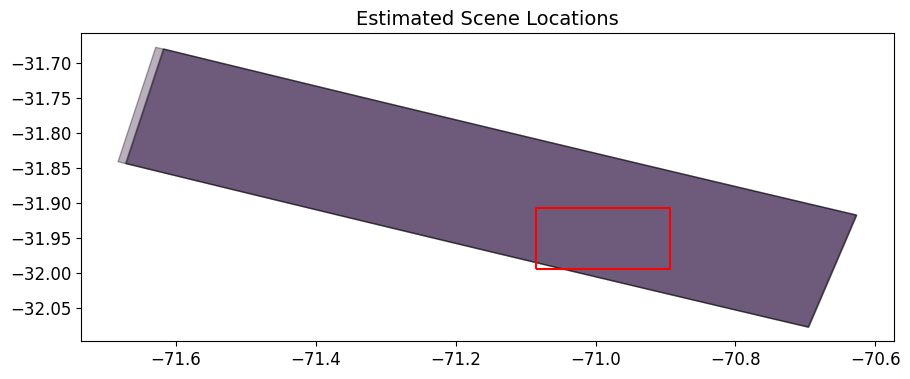

In [21]:
sbas.plot_scenes(AOI=AOI, aspect='equal')

In [22]:
sbas.load_dem(DEM, AOI)

Save DEM on WGS84 Ellipsoid:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

INFO:distributed.scheduler:Receive client connection: Client-worker-a4ca80c7-d339-11ef-97de-0242ac1c0002
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:41726


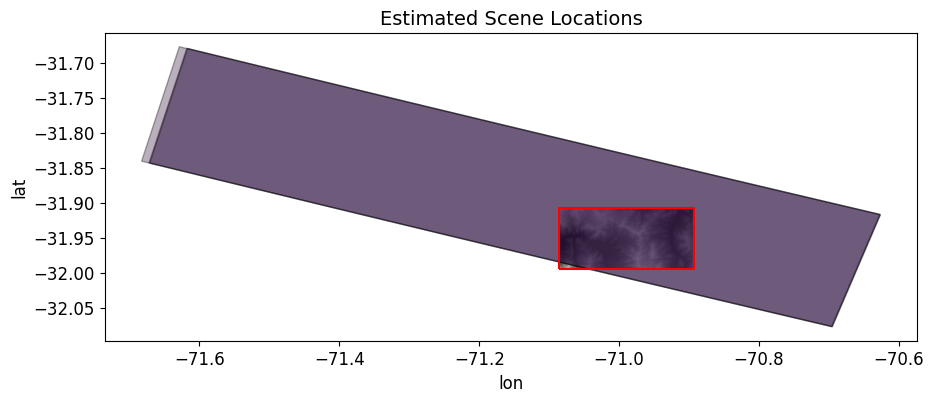

In [23]:
sbas.plot_scenes(AOI=AOI, aspect='equal')

In [24]:
sbas.compute_align()

Preparing Reference:   0%|          | 0/1 [00:00<?, ?it/s]

Aligning Repeat:   0%|          | 0/2 [00:00<?, ?it/s]

In [25]:
sbas.compute_geocode(45.)

Radar Transform Computing:   0%|          | 0/1 [00:00<?, ?it/s]

Radar Transform Saving:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

Radar Transform Indexing:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

Radar Inverse Transform Computing:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

INFO:distributed.scheduler:Receive client connection: Client-worker-bce551e9-d339-11ef-97db-0242ac1c0002
INFO:distributed.core:Starting established connection to tcp://127.0.0.1:50570


Satellite Look Vector Computing:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

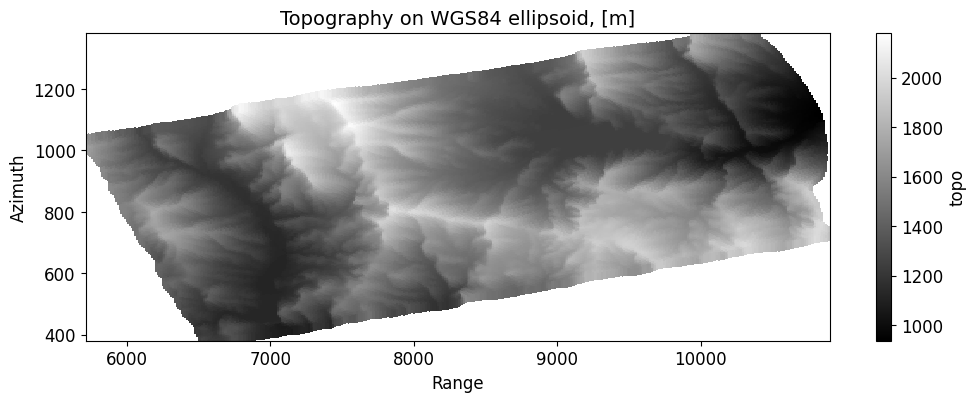

In [26]:
sbas.plot_topo()
plt.savefig('Topography in Radar Coordinates.jpg', dpi=300)

In [27]:
# define two correlation maps
pairs = np.asarray([sbas.to_dataframe().index[:-1], sbas.to_dataframe().index[1:]])
pairs = pairs.T
pairs

array([['2023-02-19', '2024-02-14'],
       ['2024-02-14', '2025-01-03']], dtype=object)

In [28]:
# load radar topography
topo = sbas.get_topo()
# load Sentinel-1 data
data = sbas.open_data()
intensity = sbas.multilooking(np.square(np.abs(data)), wavelength=400, coarsen=(3,12))
# calculate phase difference with topography correction
phase = sbas.phasediff(pairs, data, topo)
phase = sbas.multilooking(phase, wavelength=400, coarsen=(3,12))
corr = sbas.correlation(phase, intensity)
# materialize
tqdm_dask(corr := dask.persist(corr)[0], desc='Compute Correlation')
corr

Compute Correlation:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

<xarray.DataArray 'correlation' (pair: 2, y: 334, x: 431)> Size: 1MB
dask.array<concatenate, shape=(2, 334, 431), dtype=float32, chunksize=(1, 334, 431), chunktype=numpy.ndarray>
Coordinates:
    ref      (pair) datetime64[ns] 16B 2023-02-19 2024-02-14
    rep      (pair) datetime64[ns] 16B 2024-02-14 2025-01-03
  * pair     (pair) <U21 168B '2023-02-19 2024-02-14' '2024-02-14 2025-01-03'
  * y        (y) float64 3kB 381.5 384.5 387.5 ... 1.374e+03 1.378e+03 1.38e+03
  * x        (x) float64 3kB 5.724e+03 5.736e+03 ... 1.087e+04 1.088e+04

In [29]:
# geocode
corr_ll = sbas.ra2ll(corr)

In [30]:
# prepare topography and correlation
dem = sbas.get_dem().interp_like(corr_ll).where(np.isfinite(corr_ll.mean('pair')))
gmap = XYZTiles().download(dem, 12)
#.interp_like(corr_ll)

XYZ Tiles Downloading:   0%|          | 0/6 [00:00<?, ?it/s]

In [31]:
sbas.export_vtk(corr_ll[0], 'before', image=gmap)
sbas.export_vtk(corr_ll[1], 'after',  image=gmap)

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

In [32]:
# for a pair of scenes only two interferograms can be produced
# this one is selected for scenes sorted by the date in direct order
pairs = [[sbas.to_dataframe().index[i], sbas.to_dataframe().index[i+1]] for i in range(len(sbas.to_dataframe().index)-1)]
pairs

[['2023-02-19', '2024-02-14'], ['2024-02-14', '2025-01-03']]

In [33]:
# load radar topography
topo = sbas.get_topo()
# load Sentinel-1 data
data = sbas.open_data()
# Gaussian filtering 200m cut-off wavelength with multilooking 1x4 on Sentinel-1 intensity
intensity15m = sbas.multilooking(np.square(np.abs(data)), wavelength=200, coarsen=(1,4))
# calculate phase difference with topography correction
phase = sbas.phasediff(pairs, data, topo)
# Gaussian filtering 400m cut-off wavelength with 1:4 range multilooking
phase15m = sbas.multilooking(phase, wavelength=200, coarsen=(1,4))
# correlation with 1:4 range decimation to about 15m resolution
corr15m = sbas.correlation(phase15m, intensity15m)
# Goldstein filter in 32 pixel patch size on square grid cells produced using 1:4 range multilooking
phase15m_goldstein = sbas.goldstein(phase15m, corr15m, 32)
# convert complex phase difference to interferogram
intf15m = sbas.interferogram(phase15m_goldstein)
# decimate the 1:4 multilooking grids to 60m resolution
decimator = sbas.decimator()
# compute together because correlation depends on phase, and filtered phase depends on correlation.
tqdm_dask(result := dask.persist(decimator(corr15m), decimator(intf15m)), desc='Compute Phase and Correlation')
# unpack results for a single interferogram
corr60m, intf60m = [grid[0] for grid in result]

Compute Phase and Correlation:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

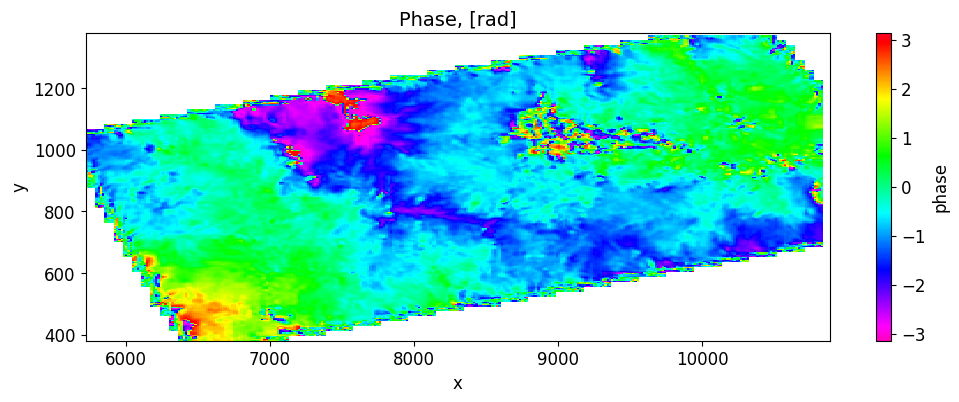

In [34]:
sbas.plot_interferogram(intf60m)
plt.savefig('Phase, [rad].jpg')

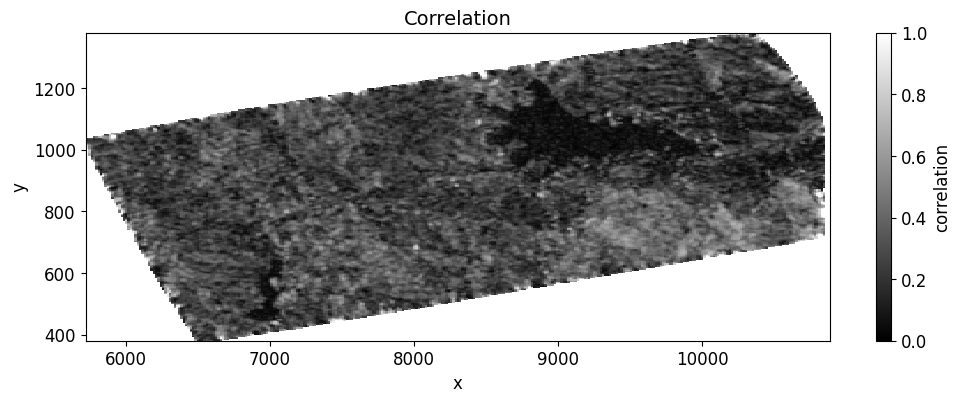

In [35]:
sbas.plot_correlation(corr60m)
plt.savefig('Correlation.jpg')

In [36]:
sbas.export_vtk(intf60m[::3,::3], 'intf')

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
# build interactive 3D plot
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(pv.read('intf.vtk').scale([1, 1, 0.00002], inplace=True), scalars='phase', cmap='turbo', ambient=0.1, show_scalar_bar=True)
plotter.show_axes()
plotter.show(screenshot='3D Interferogram.png', jupyter_backend='panel', return_viewer=True)
plotter.add_title(f'Interactive Interferogram on DEM', font_size=32)
plotter._on_first_render_request()
panel.panel(
    plotter.render_window, orientation_widget=plotter.renderer.axes_enabled,
    enable_keybindings=False, sizing_mode='stretch_width', min_height=600
)

VTKRenderWindowSynchronized(vtkXOpenGLRenderWindow, color_mappers=[LinearColorMapper(id='ba9...], min_height=600, orientation_widget=True, sizing_mode='stretch_width')

In [38]:
# mask low-coherence areas using threshold value 0.1
tqdm_dask(unwrap := sbas.unwrap_snaphu(intf60m, corr60m.where(corr60m>=0.1)).persist(), desc='SNAPHU Unwrapping')

SNAPHU Unwrapping:   0%|          | 0/9000000.0 [00:00<?, ?it/s]

In [39]:
# geocode to geographic coordinates and crop empty borders
unwrap_ll = sbas.cropna(sbas.ra2ll(unwrap.phase))

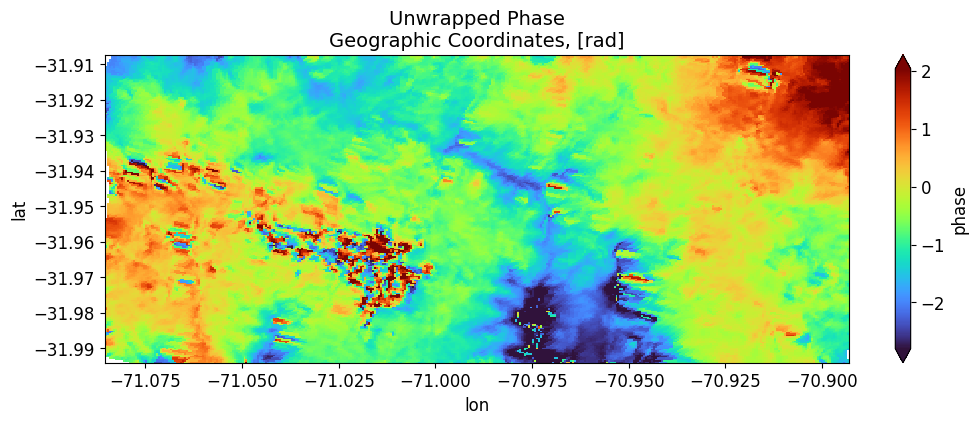

In [40]:
sbas.plot_phase(unwrap_ll, caption='Unwrapped Phase\nGeographic Coordinates, [rad]', quantile=[0.01, 0.99])

In [41]:
# geocode to geographic coordinates and crop empty borders
los_disp_mm_ll = sbas.cropna(sbas.ra2ll(sbas.los_displacement_mm(unwrap.phase)))

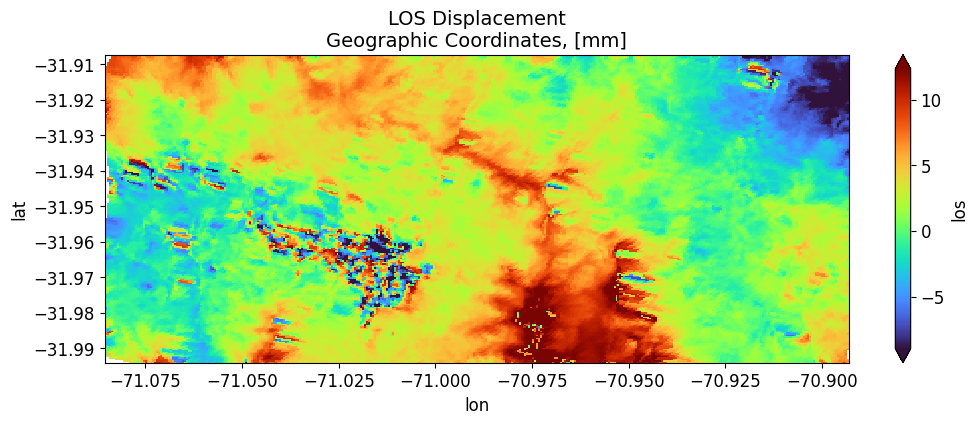

In [42]:
sbas.plot_displacement(los_disp_mm_ll, caption='LOS Displacement\nGeographic Coordinates, [mm]', quantile=[0.01, 0.99])
plt.savefig('LOS Displacement Geographic Coordinates, [mm].jpg')

In [43]:
sbas.export_vtk(los_disp_mm_ll[::3,::3], 'los')

Exporting WGS84 VTK(s):   0%|          | 0/1 [00:00<?, ?it/s]

In [44]:
# save the results
corr60m.to_netcdf('los_disp_mm_ll.nc', engine=sbas.netcdf_engine)

In [45]:
if 'google.colab' in sys.modules:
    from google.colab import files
    files.download('los_disp_mm_ll.nc')
    files.download('intf.vtk')
    files.download('los.vtk')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>